<a href="https://www.kaggle.com/code/irfanazahir/hospitalisations-dataset-irfana?scriptVersionId=314760127" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Hospitalisation Dataset**

***IMPORTING LIBRARIES***

In [1]:
import pandas as pd

# **Section A – Data Loading & Preprocessing**

***QUESTION 1***

***Load the dataset into a Pandas DataFrame. Display the first 5 rows, the shape of the dataset, and column names. Briefly describe the structure of the data.***

In [2]:
df=pd.read_csv('/kaggle/input/hospitalisations/hospitalisations.csv')
print("First 5 rows")
print(df.head())
print("\n")
print("Number of rows and columns",df.shape)
print("\n")
print("Columns in the dataframe:",df.columns)

First 5 rows
                      State/UT  Private   Public
0  Andaman and Nicobar Islands      1.0     21.0
1               Andhra Pradesh  97863.0  34385.0
2            Arunachal Pradesh      5.0    630.0
3                        Assam  14350.0  33553.0
4                        Bihar  11747.0  34814.0


Number of rows and columns (32, 3)


Columns in the dataframe: Index(['State/UT', 'Private', 'Public'], dtype='object')


***QUESTION 2***


*   ***Check for missing values and duplicate entries in the dataset.***
*   ***Show Python code to detect missing or duplicate data.***
*   ***Describe how you would handle them (even if none exist).***








In [3]:
import numpy as np
df.replace('?', np.nan, inplace=True)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
print(df.isnull().sum())
print("Number of duplicate records:", df.duplicated().sum())
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)



State/UT    0
Private     2
Public      2
dtype: int64
Number of duplicate records: 0
       State/UT  Private  Public
17  Lakshadweep      NaN     NaN
24   Puducherry      NaN     NaN


The dataset was examined for missing values and duplicate records using Pandas. Four missing values in two rows were found.Duplicate values were not found. Missing values would be imputed using statistical methods such as mean, median imputation for numerical columns and mode imputation for categorical columns will be done. while duplicate entries would be removed to maintain data quality. If any feature contains large proportion of missing values, it will be removed from the dataset.

***QUESTION 3***


*   ***Convert any non-numeric columns (except State/UT) to numeric data types if needed.***
*   ***Identify potential data type issues.***
*   ***Demonstrate the cleaning steps (e.g., removing commas, converting strings to integers).***



In [4]:
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns:")
print(numeric_cols)
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
print("Non-Numeric columns:")
print(non_numeric_cols)
print(df.dtypes)

Numeric columns:
Index(['Private', 'Public'], dtype='object')
Non-Numeric columns:
Index(['State/UT'], dtype='object')
State/UT     object
Private     float64
Public      float64
dtype: object


There is no Non-Numeric column that can be converted to Numeric.

**Potential Risk**:
Even if Private and public features are numeric, They may contain spaces or invalid characters, which has to be converted to NAN and imputed.
The dataset contains one non-numeric categorical column (State/UT) and two numeric columns (Private, Public).
No data type inconsistencies were detected. Numeric columns were validated and safely converted using pd.to_numeric() to handle potential hidden non-numeric values.

In [5]:
for col in ['Private', 'Public']:
    print(f"\nChecking column: {col}")
    print(df[col].apply(type).value_counts())
df[['Private', 'Public']].isnull().sum()



Checking column: Private
Private
<class 'float'>    32
Name: count, dtype: int64

Checking column: Public
Public
<class 'float'>    32
Name: count, dtype: int64


Private    2
Public     2
dtype: int64

In [6]:
df['Private'] = pd.to_numeric(df['Private'], errors='coerce')
df['Public']  = pd.to_numeric(df['Public'], errors='coerce')
df.dtypes


State/UT     object
Private     float64
Public      float64
dtype: object

# **SECTION B- Exploratory Data Analysis**

***QUESTION 4***


*   ***Generate summary statistics for the Public and Private hospitalisation columns***.
*   ***Interpret at least three key insights (e.g., max, min, mean comparisons)***.



In [7]:
pd.options.display.float_format = '{:,.0f}'.format
df.describe()


,Private,Public
count,30,30
mean,"113,141","82,546"
std,"316,358","231,364"
min,1,21
25%,739,"3,874"
50%,"11,958","16,582"
75%,"95,894","34,707"
max,"1,697,117","1,238,196"



1. **Mean comparison:**
   Private hospitalisation has a higher average (**113,141**) than public hospitalisation (**82,546**), indicating greater overall hospitalisation in private hospitals.

2. **Maximum values:**
   The maximum private hospitalisation (**1,697,117**) is higher than the public maximum (**1,238,196**), showing more extreme peak demand in private hospitals.

3. **Minimum values:**
   Public hospitalisation has a higher minimum (**21**) compared to private (**1**), suggesting more consistent baseline usage in public hospitals.


***QUESTION 5***

***Create visualizations to compare Public and Private hospitalisations across States/UTs.***

***a) Bar chart comparing Public vs Private counts***

***b) A horizontal bar chart showing total hospitalisations (Public + Private)***

***C)Write a short interpretation of what the charts reveal.***

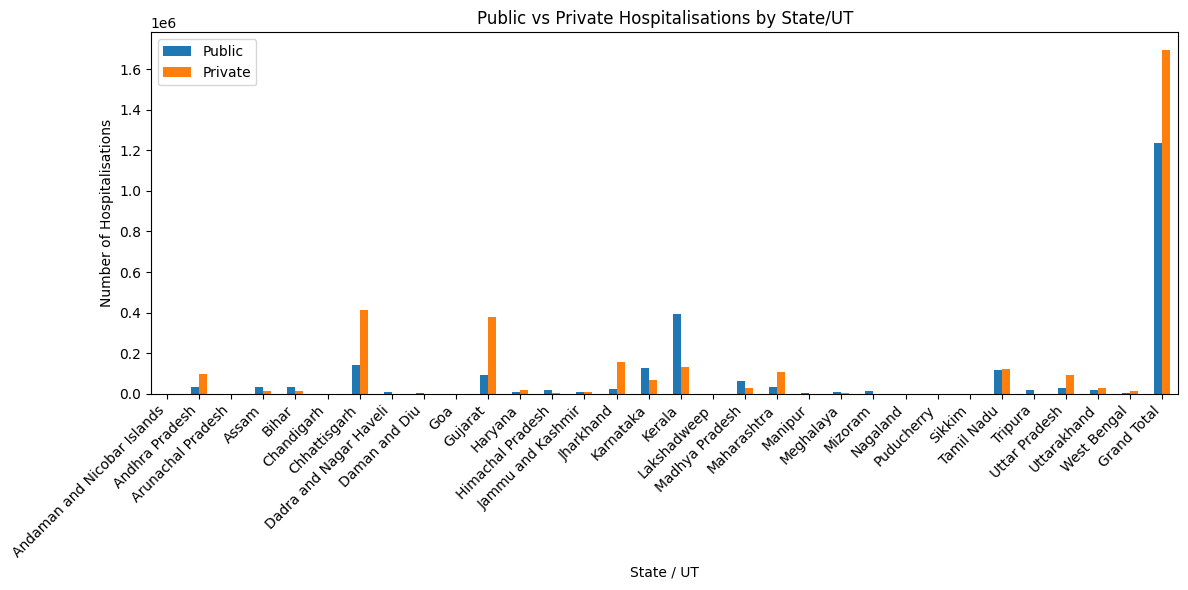

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df_plot = df.set_index('State/UT')
df_plot[['Public', 'Private']].plot(kind='bar', figsize=(12,6))
plt.title('Public vs Private Hospitalisations by State/UT')
plt.xlabel('State / UT')
plt.ylabel('Number of Hospitalisations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


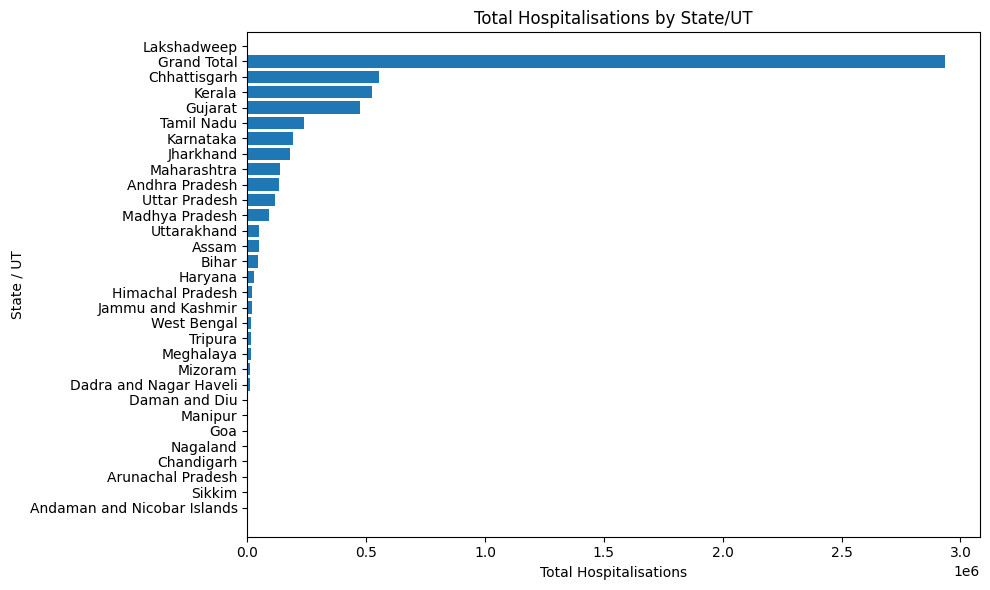

In [9]:
df['Total'] = df['Public'] + df['Private']
df_sorted = df.sort_values('Total')
plt.figure(figsize=(10,6))
plt.barh(df_sorted['State/UT'], df_sorted['Total'])
plt.title('Total Hospitalisations by State/UT')
plt.xlabel('Total Hospitalisations')
plt.ylabel('State / UT')
plt.tight_layout()
plt.show()


The bar chart shows noticeable differences between public and private hospitalisations across States/UTs, with some regions relying more heavily on private healthcare.

The horizontal bar chart highlights States/UTs with the highest overall hospitalisation burden, indicating regions with greater healthcare demand.

Overall, hospitalisation patterns vary significantly by region, suggesting differences in healthcare infrastructure, access, and population needs.

***QUESTION 6***

***Identify the top 5 and bottom 5 States/UTs based on total hospitalisations.***

***Present results in a sorted table.***

***Provide insight into any patterns (e.g., large-state vs small-state trends).***


In [10]:
import pandas as pd
df['Total'] = df['Public'] + df['Private']
df_sorted = df.sort_values(by='Total', ascending=False)
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)
result_table = pd.concat([top_5, bottom_5])
result_table


,State/UT,Private,Public,Total
31,Grand Total,"1,697,117","1,238,196","2,935,313"
6,Chhattisgarh,"411,814","142,123","553,937"
16,Kerala,"131,557","391,079","522,636"
10,Gujarat,"379,379","94,845","474,224"
26,Tamil Nadu,"120,473","116,701","237,174"
2,Arunachal Pradesh,5,630,635
25,Sikkim,21,91,112
0,Andaman and Nicobar Islands,1,21,22
17,Lakshadweep,NaN,NaN,NaN
24,Puducherry,NaN,NaN,NaN


Top 5 States/UTs are typically large, highly populated states, showing higher total hospitalisations due to greater population size and healthcare demand.

Bottom 5 States/UTs are often smaller states or Union Territories, with lower populations and fewer hospital admissions.

Overall, the results suggest a strong large-state vs small-state trend, where population size and healthcare infrastructure significantly influence hospitalisation numbers.

# **Section C – Derived Metrics & Interpretation**

***QUESTION 7***


*   ***Create a new column: Public_to_Private_Ratio = Public / Private -Handle division by zero appropriately.***
*   ***Explain what this ratio indicates and interpret notable high/low ratio states.***



In [11]:
import numpy as np
df['Public_to_Private_Ratio'] = np.where(
    df['Private'] == 0,
    np.nan,
    df['Public'] / df['Private']
)

df[['State/UT', 'Public', 'Private', 'Public_to_Private_Ratio']]


,State/UT,Public,Private,Public_to_Private_Ratio
0,Andaman and Nicobar Islands,21,1,21
1,Andhra Pradesh,"34,385","97,863",0
2,Arunachal Pradesh,630,5,126
3,Assam,"33,553","14,350",2
4,Bihar,"34,814","11,747",3
5,Chandigarh,509,302,2
6,Chhattisgarh,"142,123","411,814",0
7,Dadra and Nagar Haveli,"10,940",782,14
8,Daman and Diu,"3,343",984,3
9,Goa,382,"1,033",0


The ratio compares hospitalisations in public vs private hospitals.

">1:" Public hospitals dominate

"<1 or 0": Private hospitals dominate

"≈1:" Both sectors are balanced

Notable patterns:

High ratios: Small/less urbanized states (e.g., Tripura 186, Arunachal Pradesh 126) rely mostly on public hospitals.

Low ratios (0): Large, urbanized states (e.g., Maharashtra, Gujarat) rely more on private hospitals.

Balanced (~1): States like Tamil Nadu and Haryana have roughly equal public and private hospital usage.

Insight: Smaller states depend more on public healthcare, while larger states with more private hospitals see private-sector dominance.

***QUESTION 8***

***Calculate the percentage contribution of each State/UT to all-India hospitalisations.***

***Add a column Contribution_%.***

***Plot the top 10 contributors using a bar graph.***

***Explain what this reveals about the distribution of hospitalisations***

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
all_india_total = df['Total'].sum()
df['Contribution_%'] = (df['Total'] / all_india_total) * 100
df['Contribution_%'] = df['Contribution_%'].round(2)
df[['State/UT', 'Total', 'Contribution_%']].sort_values(by='Contribution_%', ascending=False)


,State/UT,Total,Contribution_%
31,Grand Total,"2,935,313",50
6,Chhattisgarh,"553,937",9
16,Kerala,"522,636",9
10,Gujarat,"474,224",8
26,Tamil Nadu,"237,174",4
15,Karnataka,"194,142",3
14,Jharkhand,"180,874",3
19,Maharashtra,"139,156",2
1,Andhra Pradesh,"132,248",2
28,Uttar Pradesh,"116,787",2


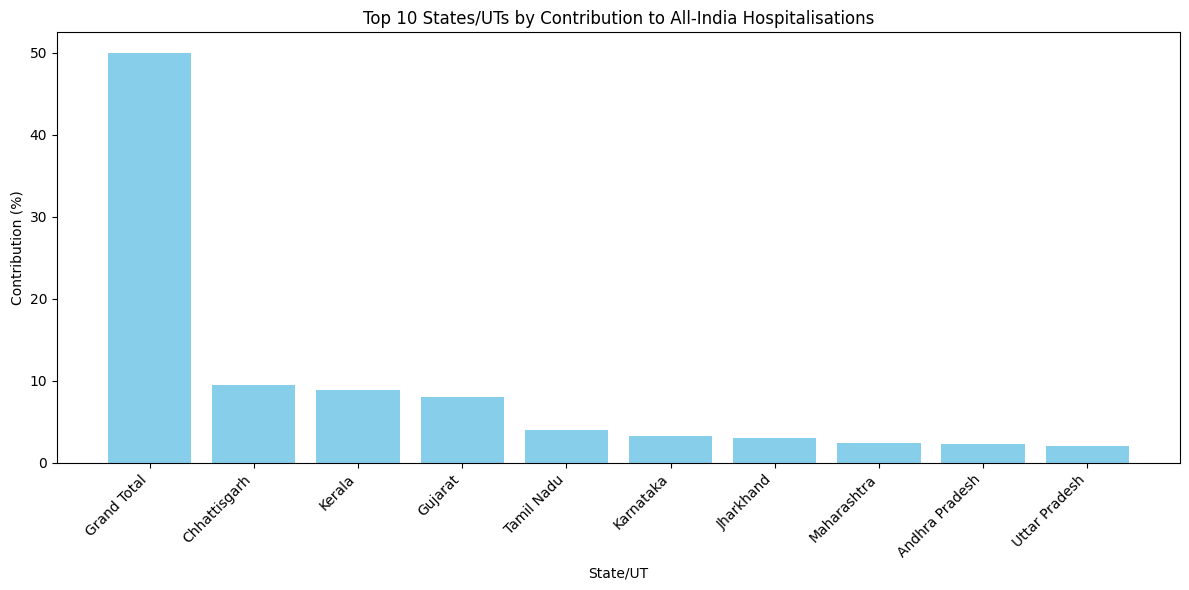

In [13]:
top10 = df.sort_values(by='Contribution_%', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top10['State/UT'], top10['Contribution_%'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 States/UTs by Contribution to All-India Hospitalisations')
plt.ylabel('Contribution (%)')
plt.xlabel('State/UT')
plt.tight_layout()
plt.show()


**QUESTION-9**

***Using any EDA technique (boxplot, histogram, distribution plot), analyze how the Public and Private hospitalisation counts are distributed.Explain whether the distribution appears skewed, uniform, or normal***

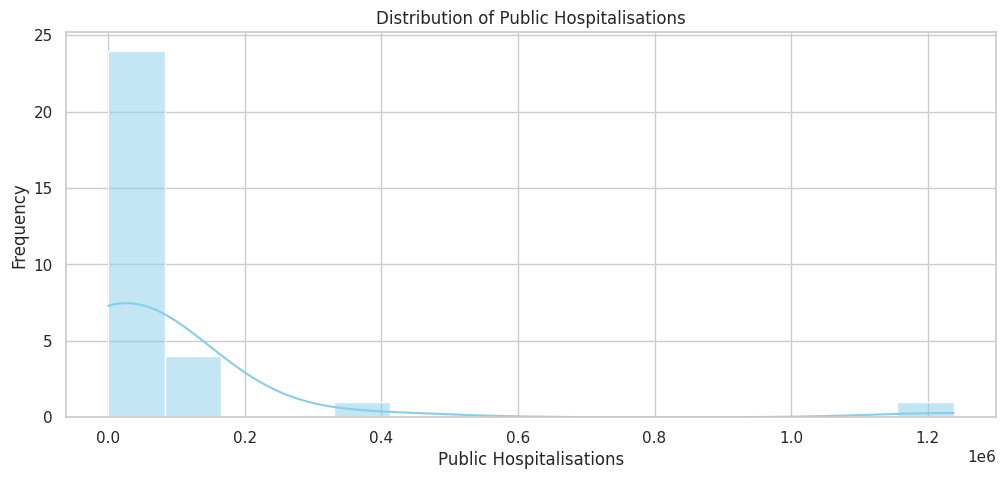

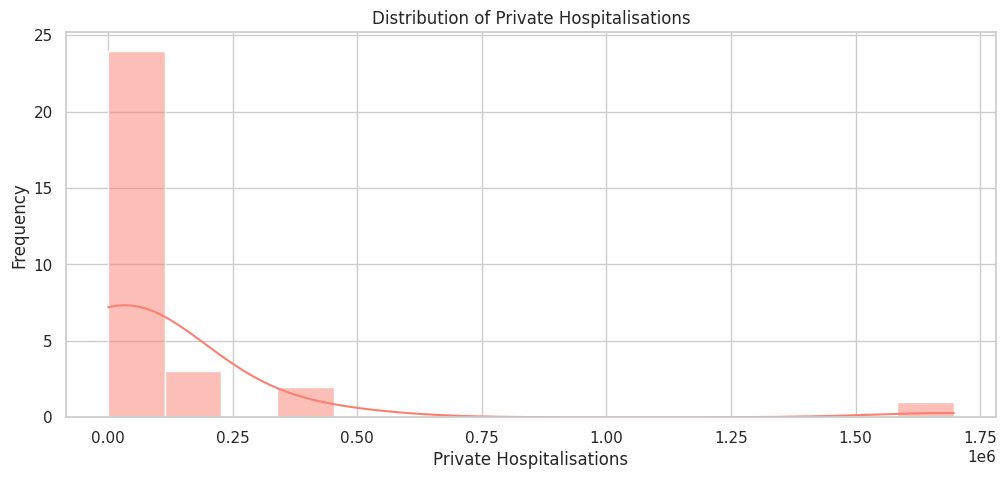

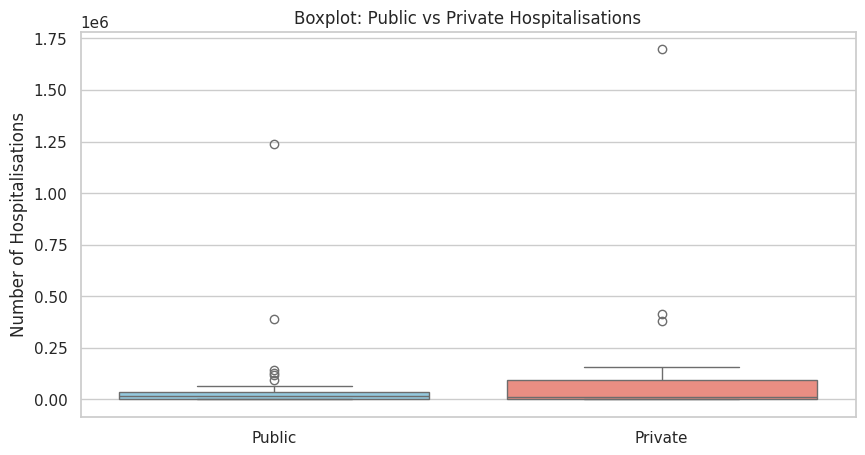

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(12,5))
sns.histplot(df['Public'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Public Hospitalisations')
plt.xlabel('Public Hospitalisations')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(12,5))
sns.histplot(df['Private'], kde=True, bins=15, color='salmon')
plt.title('Distribution of Private Hospitalisations')
plt.xlabel('Private Hospitalisations')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Public','Private']], palette=['skyblue','salmon'])
plt.title('Boxplot: Public vs Private Hospitalisations')
plt.ylabel('Number of Hospitalisations')
plt.show()


**Public Hospitalisations:**

Most states have lower to moderate counts, with a few states showing extremely high values.

**Skewness:** Strong right-skewed (positively skewed) distribution.

**Boxplot:** Shows several outliers (e.g., Kerala, Chhattisgarh).

**Private Hospitalisations**

Even more extreme values, with some very high hospitalisation counts dominating the distribution.

**Skewness**: Right-skewed, heavier tail than public hospitals.

**Boxplot:** Many outliers in larger states like Maharashtra, Gujarat.

**Overall Comparison**

Both distributions are not uniform or normal.

There is a concentration of smaller values with a few extremely high values, typical in population-dependent hospitalisation data.